In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [28]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv(r"C:\Users\Shaambhavi Srivastav\Downloads\car data.csv")

In [29]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [30]:
car_dataset.shape #checking number of rows and columns

(301, 9)

In [31]:
car_dataset.sample

<bound method NDFrame.sample of     Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1  

In [32]:
#getting some information about dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [33]:
# checking the number of null values
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [34]:
# checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())
      

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [35]:
# encoding "Fuel_Type" column
car_dataset.replace({'Fuel_Type' :{'Petrol':0, 'Diesel' :1, 'CNG':2}}, inplace =True)
# encoding "Seller_Type column
car_dataset.replace({'Seller_Type' :{'Dealer' :0, 'Individual ' :1}}, inplace = True)
#encoding "Transmission" column
car_dataset.replace({'Transmission' :{'Manual': 0, 'Automatic' :1}}, inplace = True)

C:\Users\Shaambhavi Srivastav\AppData\Local\Temp\ipykernel_4308\1530951610.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type' :{'Petrol':0, 'Diesel' :1, 'CNG':2}}, inplace =True)
C:\Users\Shaambhavi Srivastav\AppData\Local\Temp\ipykernel_4308\1530951610.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Transmission' :{'Manual': 0, 'Automatic' :1}}, inplace = True)


In [36]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [37]:
 X = car_dataset.drop(['Car_Name' , 'Selling_Price',] ,axis=1)
 Y = car_dataset['Selling_Price']                      

In [38]:
print(X)

     Year  Present_Price  Kms_Driven  Fuel_Type Seller_Type  Transmission  \
0    2014           5.59       27000          0           0             0   
1    2013           9.54       43000          1           0             0   
2    2017           9.85        6900          0           0             0   
3    2011           4.15        5200          0           0             0   
4    2014           6.87       42450          1           0             0   
..    ...            ...         ...        ...         ...           ...   
296  2016          11.60       33988          1           0             0   
297  2015           5.90       60000          0           0             0   
298  2009          11.00       87934          0           0             0   
299  2017          12.50        9000          1           0             0   
300  2016           5.90        5464          0           0             0   

     Owner  
0        0  
1        0  
2        0  
3        0  
4        0

In [39]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size =0.1, random_state=2)

In [44]:
#loading the linear regression model
lin_reg_model = LinearRegression()


In [46]:
# Force-encode any remaining text strings in the dataset
car_dataset.replace({'Seller_Type': {'Dealer': 0, 'Individual': 1}}, inplace=True)

# Re-split the clean data so X_train updates in memory
X = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)
Y = car_dataset['Selling_Price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)

# Now train the model
lin_reg_model.fit(X_train, Y_train)

C:\Users\Shaambhavi Srivastav\AppData\Local\Temp\ipykernel_4308\3035570825.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type': {'Dealer': 0, 'Individual': 1}}, inplace=True)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [49]:
# R ssquared error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ",error_score)

R squared Error :  0.87994516604937


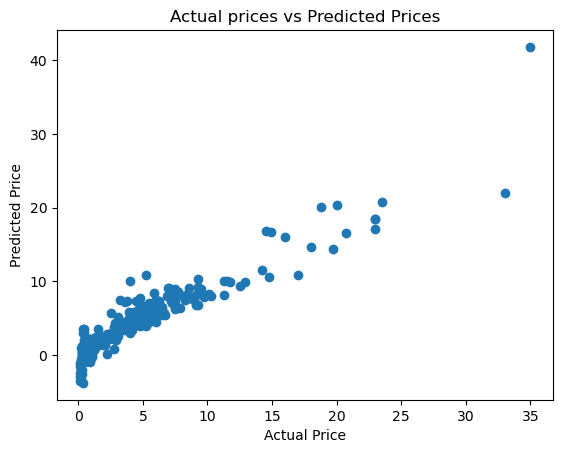

In [51]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual prices vs Predicted Prices")
plt.show()

In [52]:
#prediction on trainung data
test_data_prediction = lin_reg_model.predict(X_test)

In [54]:
#R squared error
error_source = metrics.r2_score(Y_test,test_data_prediction)
print("R squared Error : " , error_source)

R squared Error :  0.8365766715025409


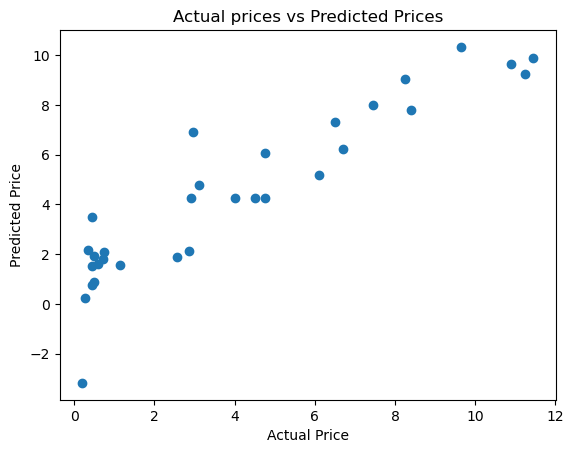

In [56]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual prices vs Predicted Prices")
plt.show()

In [58]:
#Loading the linear regression model(Lasso Regression)
lass_reg_model = Lasso()

In [59]:
lass_reg_model.fit(X_train, Y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [60]:
#Predicting on training data
training_data_prediction = lass_reg_model.predict(X_train)

In [61]:
# R squared error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ",error_score)

R squared Error :  0.8427856123435794


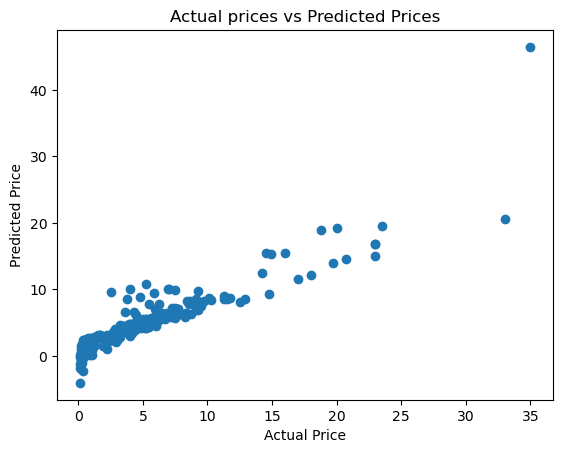

In [62]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual prices vs Predicted Prices")
plt.show()

In [63]:
#prediction on test data
test_data_prediction = lass_reg_model.predict(X_test)

In [64]:
#R Squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8709167941173195


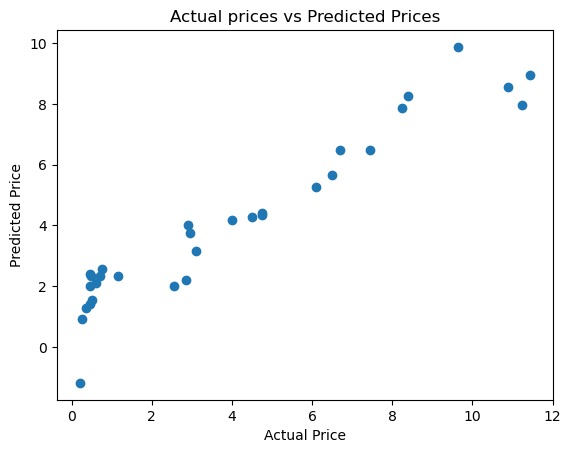

In [65]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual prices vs Predicted Prices")
plt.show()